In [62]:
%reset -f

In [63]:
import os
import cv2
import pytesseract
import numpy as np
from glob import glob
from PIL import Image
from matplotlib import pyplot as plt

In [64]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [65]:
def extract_text_from_frames(frames_path):
    myconfig = r'--oem 3 --psm 6'  
    cout     = 0
    all_text = ""
    
    for image_file in os.listdir(frames_path):
        
        image_path = os.path.join(frames_path, f"page_{cout}.png")
        if os.path.exists(image_path):
            img       = Image.open(image_path)
            text      = pytesseract.image_to_string(img, config=myconfig)
            all_text += text 
            
        cout += 1 
    return all_text

In [66]:
def save_to_text(text, output_file_path, file_name="output"):
    create_dir(output_file_path)
    with open(f"{output_file_path}/{file_name}.txt", "w", encoding="utf-8") as f:
        f.write(text)
    return f"{output_file_path}/{file_name}.txt"


In [57]:
def get_score(original,duplicate ):
    diff = cv2.absdiff(original, duplicate)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    score = diff.mean()
    return score

In [61]:
import cv2
import os

def get_score(original, duplicate):

    diff = cv2.absdiff(original, duplicate)

    score = diff.mean()

    return score


img1 = cv2.imread(
    os.path.join(o_dir, r"Chapter 1\page_1724.png")
)

img2 = cv2.imread(
    os.path.join(o_dir, r"Chapter 1\page_1725.png")
)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

print(get_score(gray1, gray2))

img1 = None

img2 = None

0.0006336805555555555


In [43]:
def get_scores(video_path):
    cap = cv2.VideoCapture(video_path)
    prev = None
    scores = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev is not None:
            scores.append(cv2.absdiff(prev, gray).mean())

        prev = gray

    cap.release()
    return scores

Mean: 0.12, Median: 0.00, Std: 1.42, Max: 20.40
Suggested threshold using the mean and std is : 2.96
Suggested threshold using 95 percentile is : 16.46


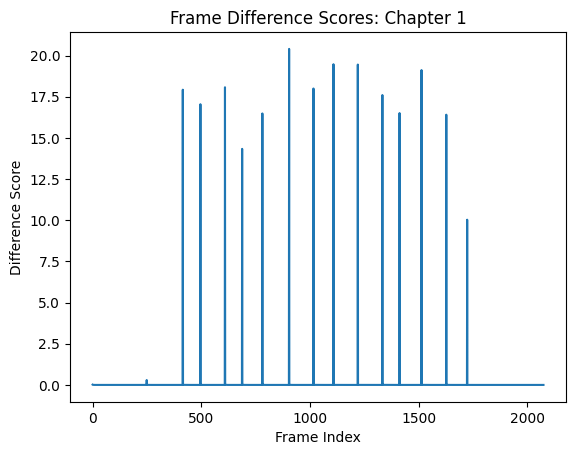

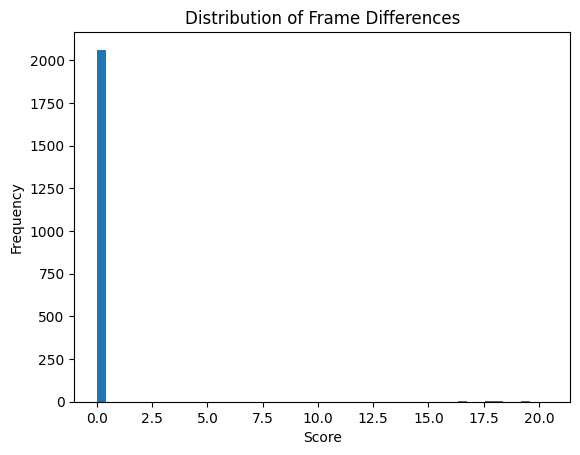

 DONE


In [48]:
video_Folder_path     = r"C:\Users\MIL\Videos\OBS"
output_img_path       = r"C:\Users\MIL\Documents\Python OutPut Images"
output_txt_path       = r"C:\Users\MIL\Documents\Python OutPut Files"
text = ""
matches = glob(video_Folder_path)
if matches:
    for folder in matches:
        for item in glob(os.path.join(folder, "*")):
            stat_array = get_scores(item)

            mean = np.mean(stat_array)
            median = np.median(stat_array)
            std = np.std(stat_array)
            max_val = np.max(stat_array)
        
            print(f"Mean: {mean:.2f}, Median: {median:.2f}, Std: {std:.2f}, Max: {max_val:.2f}")
        
            # Auto threshold
            mean_std_threshold = mean + 2 * std
            percentile_threshold = np.percentile(stat_array, 99.5)
            print(f"Suggested threshold using the mean and std is : {mean_std_threshold:.2f}")
            print(f"Suggested threshold using 95 percentile is : {percentile_threshold:.2f}")
        
            plt.plot(stat_array)
            plt.title(f"Frame Difference Scores: {video_name}")
            plt.xlabel("Frame Index")
            plt.ylabel("Difference Score")
            plt.show()
        
            plt.hist(stat_array, bins=50)
            plt.title("Distribution of Frame Differences")
            plt.xlabel("Score")
            plt.ylabel("Frequency")
            plt.show()
    
            
print(" DONE")

In [47]:
video_Folder_path     = r"C:\Users\MIL\Videos\OBS"
output_img_path       = r"C:\Users\MIL\Documents\Python OutPut Images"
output_txt_path       = r"C:\Users\MIL\Documents\Python OutPut Files"
text = ""
matches = glob(video_Folder_path)
if matches:
    for folder in matches:
        for item in glob(os.path.join(folder, "*")):
            frames_path = Video_To_frames(item,output_img_path,0.01)
            print(f" extracted frames to {frames_path} ")
            #text       = extract_text_from_frames(frames_path)
            print(f" extracted text ")
            video_name = os.path.splitext(os.path.basename(item))[0]
            #text_path = save_to_text(text,output_txt_path,video_name)
            #print(f" saved the text to to {text_path} ")  
print(" DONE")

Score  0.01679036458333333
Score  0.005477430555555556
Score  0.004178602430555556
Score  0.004526909722222222
Score  0.00023763020833333335
Score  0.00020833333333333335
Score  0.00017903645833333332
Score  0.00024305555555555555
Score  0.00021375868055555555
Score  0.00016710069444444444
Score  0.00017903645833333332
Score  0.0002072482638888889
Score  0.296591796875
Score  0.012394748263888889
Score  0.003988715277777778
Score  0.003042534722222222
Score  0.003240017361111111
Score  0.00023328993055555557
Score  0.00023111979166666666
Score  0.00022026909722222223
Score  0.00026584201388888887
Score  17.926455078125
Score  0.01017361111111111
Score  0.00462890625
Score  0.00361328125
Score  0.0037109375
Score  0.00013129340277777778
Score  0.00012044270833333334
Score  0.00011067708333333333
Score  0.00013997395833333334
Score  5.4253472222222224e-06
Score  9.765625e-06
Score  17.045656467013888
Score  0.004219835069444444
Score  0.0024055989583333334
Score  0.0018587239583333333
Sc

In [72]:
import os
import cv2

def Video_To_frames(video_path, output_path):
    video_name      = os.path.splitext(os.path.basename(video_path))[0]
    save_path       = os.path.join(output_path, video_name)

    create_dir(save_path)
    cap = cv2.VideoCapture(video_path)

    prev_gray  = None
    prev_img   = None
    page_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev_gray is None:
            cv2.imwrite(os.path.join(save_path, f"page_{page_count}.png"), frame)
            page_count += 1
            prev_gray = gray
            prev_img = frame
            continue

        diff = cv2.absdiff(prev_gray, gray)
        score = diff.mean()

        if score != 0:
            cv2.imwrite(os.path.join(save_path, f"page_{page_count}.png"), prev_img)
            prev_img = frame
            prev_gray = gray
            page_count += 1
    cap.release()
    return save_path

In [73]:
dir_ = r"C:\Users\MIL\Videos\OBS\Chapter 1.mp4"
o_dir = r"C:\Users\MIL\Videos\OBS"

frames_dir = Video_To_frames(dir_, o_dir)

In [80]:
import os
import re
import shutil
import pytesseract

from PIL import Image
from difflib import SequenceMatcher


def clean_text(text):

    text = text.lower()

    text = re.sub(r'\s+', ' ', text)

    return text.strip()


def get_page_signature(text, length=150):

    text = clean_text(text)

    return text[:length]


def filter_duplicate_pages(frames_path, similarity_threshold=0.60 ):

    unique_dir = os.path.join(frames_path,"unique_pages" )

    os.makedirs(unique_dir, exist_ok=True)

    previous_signature = ""

    myconfig = r'--oem 3 --psm 6'

    cout = 0
    page_count = 0
    for image_file in os.listdir(frames_path):

        print(cout)
        
        image_path = os.path.join(frames_path, f"page_{cout}.png")

        img       = Image.open(image_path)
        text      = pytesseract.image_to_string(img,config=myconfig )
        signature = get_page_signature(text)

        similarity = SequenceMatcher( None, signature,previous_signature).ratio()
        if similarity < similarity_threshold:

            new_name  = f"page_{page_count}.png"
            save_path = os.path.join( unique_dir,new_name)
            shutil.copy(image_path, save_path)
            print(f"KEEP: {image_path}")
            previous_signature = signature
            page_count += 1
        cout += 1

    return unique_dir

In [81]:
unique_dir = filter_duplicate_pages(frames_dir)

print(unique_dir)

0
KEEP: page_0.png
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
KEEP: page_119.png
24
25
26
27
28
29
30
31
32
33
34
KEEP: page_129.png
35
36
37
38
39
40
41
42
43
44
45
KEEP: page_139.png
46
47
48
49
50
51
52
53
54
55
56
KEEP: page_149.png
57
58
59
60
61
62
63
64
65
KEEP: page_157.png
66
67
68
69
70
71
72
73
74
75
76
77
KEEP: page_168.png
78
79
80
81
82
83
84
85
86
87
88
89
90
91
KEEP: page_180.png
92
93
94
95
96
97
98
99
100
101
102
KEEP: page_190.png
103
104
105
106
107
108
109
110
111
112
113
114
115
KEEP: page_3.png
116
117
118
119
120
121
122
123
124
125
126
127
128
129
KEEP: page_42.png
130
131
132
133
134
135
136
137
138
139
140
141
142
KEEP: page_54.png
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
KEEP: page_68.png
158
159
160
161
162
163
164
165
166
167
168
169
170
KEEP: page_8.png
171
172
173
174
175
176
177
178
179
KEEP: page_88.png
180
181
182
183
184
185
186
187
188
189
190
191
192


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\MIL\\Videos\\OBS\\Chapter 1\\page_192.png'